In [ ]:
#Import Libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')


In [ ]:
#Connect to SQLite database
con = sqlite3.connect('travel.sqlite')
cursor = con.cursor()

In [ ]:
#Printing the List of Tables in the Database
cursor.execute("""select name from sqlite_master where type ='table';""")
print('List of tables present in the database') 
table_list = [table[0] for table in cursor.fetchall()]

table_list

List of tables present in the database


['aircrafts_data',
 'airports_data',
 'boarding_passes',
 'bookings',
 'flights',
 'seats',
 'ticket_flights',
 'tickets']

## Data Exploration

In [ ]:
#Loading aircraft_data Table
aircrafts_data = pd.read_sql_query("SELECT * From aircrafts_data", con)
aircrafts_data

,aircraft_code,model,range
0,773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
1,763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
2,SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суп...",3000
3,320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-...",5700
4,321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-...",5600
5,319,"{""en"": ""Airbus A319-100"", ""ru"": ""Аэробус A319-...",6700
6,733,"{""en"": ""Boeing 737-300"", ""ru"": ""Боинг 737-300""}",4200
7,CN1,"{""en"": ""Cessna 208 Caravan"", ""ru"": ""Сессна 208...",1200
8,CR2,"{""en"": ""Bombardier CRJ-200"", ""ru"": ""Бомбардье ...",2700


In [ ]:
#Loading airfort_data Table
airports_data = pd.read_sql_query("SELECT * From airports_data", con)
airports_data.head()

,airport_code,airport_name,city,coordinates,timezone
0,YKS,"{""en"": ""Yakutsk Airport"", ""ru"": ""Якутск""}","{""en"": ""Yakutsk"", ""ru"": ""Якутск""}","(129.77099609375,62.0932998657226562)",Asia/Yakutsk
1,MJZ,"{""en"": ""Mirny Airport"", ""ru"": ""Мирный""}","{""en"": ""Mirnyj"", ""ru"": ""Мирный""}","(114.03900146484375,62.534698486328125)",Asia/Yakutsk
2,KHV,"{""en"": ""Khabarovsk-Novy Airport"", ""ru"": ""Хабар...","{""en"": ""Khabarovsk"", ""ru"": ""Хабаровск""}","(135.18800354004,48.5279998779300001)",Asia/Vladivostok
3,PKC,"{""en"": ""Yelizovo Airport"", ""ru"": ""Елизово""}","{""en"": ""Petropavlovsk"", ""ru"": ""Петропавловск-К...","(158.453994750976562,53.1679000854492188)",Asia/Kamchatka
4,UUS,"{""en"": ""Yuzhno-Sakhalinsk Airport"", ""ru"": ""Хом...","{""en"": ""Yuzhno-Sakhalinsk"", ""ru"": ""Южно-Сахали...","(142.718002319335938,46.8886985778808594)",Asia/Sakhalin


In [ ]:
#Loading boarding_passes Table
boarding_passes = pd.read_sql_query("SELECT * From boarding_passes", con)
boarding_passes.head()

,ticket_no,flight_id,boarding_no,seat_no
0,0005435212351,30625,1,2D
1,0005435212386,30625,2,3G
2,0005435212381,30625,3,4H
3,0005432211370,30625,4,5D
4,0005435212357,30625,5,11A


In [ ]:
#Loading bookings Table
bookings = pd.read_sql_query("SELECT * From bookings", con)
bookings.head()

,book_ref,book_date,total_amount
0,00000F,2017-07-05 03:12:00+03,265700
1,000012,2017-07-14 09:02:00+03,37900
2,000068,2017-08-15 14:27:00+03,18100
3,000181,2017-08-10 13:28:00+03,131800
4,0002D8,2017-08-07 21:40:00+03,23600


In [ ]:
#Loading flights Table
flights = pd.read_sql_query("SELECT * From flights", con)
flights.head()

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,1185,PG0134,2017-09-10 09:50:00+03,2017-09-10 14:55:00+03,DME,BTK,Scheduled,319,\N,\N
1,3979,PG0052,2017-08-25 14:50:00+03,2017-08-25 17:35:00+03,VKO,HMA,Scheduled,CR2,\N,\N
2,4739,PG0561,2017-09-05 12:30:00+03,2017-09-05 14:15:00+03,VKO,AER,Scheduled,763,\N,\N
3,5502,PG0529,2017-09-12 09:50:00+03,2017-09-12 11:20:00+03,SVO,UFA,Scheduled,763,\N,\N
4,6938,PG0461,2017-09-04 12:25:00+03,2017-09-04 13:20:00+03,SVO,ULV,Scheduled,SU9,\N,\N


In [ ]:
#Loading seats Table
seats = pd.read_sql_query("SELECT * From seats", con)
seats

,aircraft_code,seat_no,fare_conditions
0,319,2A,Business
1,319,2C,Business
2,319,2D,Business
3,319,2F,Business
4,319,3A,Business
...,...,...,...
1334,773,48H,Economy
1335,773,48K,Economy
1336,773,49A,Economy
1337,773,49C,Economy


In [ ]:
#Loading tickets_flights Table
ticket_flights = pd.read_sql_query("SELECT * From ticket_flights", con)
ticket_flights.head()

,ticket_no,flight_id,fare_conditions,amount
0,0005432159776,30625,Business,42100
1,0005435212351,30625,Business,42100
2,0005435212386,30625,Business,42100
3,0005435212381,30625,Business,42100
4,0005432211370,30625,Business,42100


In [ ]:
#Loading tickets Table
tickets = pd.read_sql_query("SELECT * From tickets", con)
tickets.head()

,ticket_no,book_ref,passenger_id
0,0005432000987,06B046,8149 604011
1,0005432000988,06B046,8499 420203
2,0005432000989,E170C3,1011 752484
3,0005432000990,E170C3,4849 400049
4,0005432000991,F313DD,6615 976589


In [12]:
for table in table_list:
    print("/ntable: ", table)
column_info = con.execute("PRAGMA table_info({})".format(table))
for column in column_info.fetchall():
    print(column[1:3])

/ntable:  aircrafts_data
/ntable:  airports_data
/ntable:  boarding_passes
/ntable:  bookings
/ntable:  flights
/ntable:  seats
/ntable:  ticket_flights
/ntable:  tickets
('ticket_no', 'character(13)')
('book_ref', 'character(6)')
('passenger_id', 'character varying(20)')


In [13]:
#Checking the Data type for all columns of all the tables
for table in table_list:
    print("\nTable:", table)
    
    column_info = con.execute(f"PRAGMA table_info({table})")
    
    for column in column_info.fetchall():
        print(column[1:3])


Table: aircrafts_data
('aircraft_code', 'character(3)')
('model', 'jsonb')
('range', 'INTEGER')

Table: airports_data
('airport_code', 'character(3)')
('airport_name', 'jsonb')
('city', 'jsonb')
('coordinates', 'point')
('timezone', 'TEXT')

Table: boarding_passes
('ticket_no', 'character(13)')
('flight_id', 'INTEGER')
('boarding_no', 'INTEGER')
('seat_no', 'character varying(4)')

Table: bookings
('book_ref', 'character(6)')
('book_date', 'timestamp with time zone')
('total_amount', 'numeric(10,2)')

Table: flights
('flight_id', 'INTEGER')
('flight_no', 'character(6)')
('scheduled_departure', 'timestamp with time zone')
('scheduled_arrival', 'timestamp with time zone')
('departure_airport', 'character(3)')
('arrival_airport', 'character(3)')
('status', 'character varying(20)')
('aircraft_code', 'character(3)')
('actual_departure', 'timestamp with time zone')
('actual_arrival', 'timestamp with time zone')

Table: seats
('aircraft_code', 'character(3)')
('seat_no', 'character varying(4

In [14]:
for table in table_list:
    print('/ntable: ', table)
    df_table = pd.read_sql_query(f"select * from {table}", con)
    print(df_table.isnull().sum())


/ntable:  aircrafts_data
aircraft_code    0
model            0
range            0
dtype: int64
/ntable:  airports_data
airport_code    0
airport_name    0
city            0
coordinates     0
timezone        0
dtype: int64
/ntable:  boarding_passes
ticket_no      0
flight_id      0
boarding_no    0
seat_no        0
dtype: int64
/ntable:  bookings
book_ref        0
book_date       0
total_amount    0
dtype: int64
/ntable:  flights
flight_id              0
flight_no              0
scheduled_departure    0
scheduled_arrival      0
departure_airport      0
arrival_airport        0
status                 0
aircraft_code          0
actual_departure       0
actual_arrival         0
dtype: int64
/ntable:  seats
aircraft_code      0
seat_no            0
fare_conditions    0
dtype: int64
/ntable:  ticket_flights
ticket_no          0
flight_id          0
fare_conditions    0
amount             0
dtype: int64
/ntable:  tickets
ticket_no       0
book_ref        0
passenger_id    0
dtype: int64


# Basic Analysis
The basic analysis of the data provides insights into the number of planes with more than 100 seats, how the number of tickets booked and total amount earned changed over time, and the average fare for each aircraft with different fare conditions. These findings will be useful in developing strategies to increase occupancy rates and optimize pricing for each aircraft.

#### 1. How many planes have more than 100 seats?

In [15]:
pd.read_sql_query("""select aircraft_code, count(*) as num_seats from seats
                  group by aircraft_code having num_seats > 100""", con)

,aircraft_code,num_seats
0,319,116
1,320,140
2,321,170
3,733,130
4,763,222
5,773,402


#### 2. How the number of tickets booked and total amount earned changed over time?

In [ ]:
# Joining tickets table with bookings table with inner join using book_ref as the common connector.
tickets = pd.read_sql_query("""select * from tickets inner join bookings
                  on tickets.book_ref=bookings.book_ref""", con)

In [17]:
#changing the data type of book_date form object to datetime
tickets['book_date'] = pd.to_datetime(tickets['book_date'])

In [18]:
#making a date column seperately which have only date in it from the datetime column
tickets['date'] = tickets['book_date'].dt.date

In [19]:
# grouping by new date only column and counting the total bookings
date_group = tickets.groupby('date')[['date']].count()


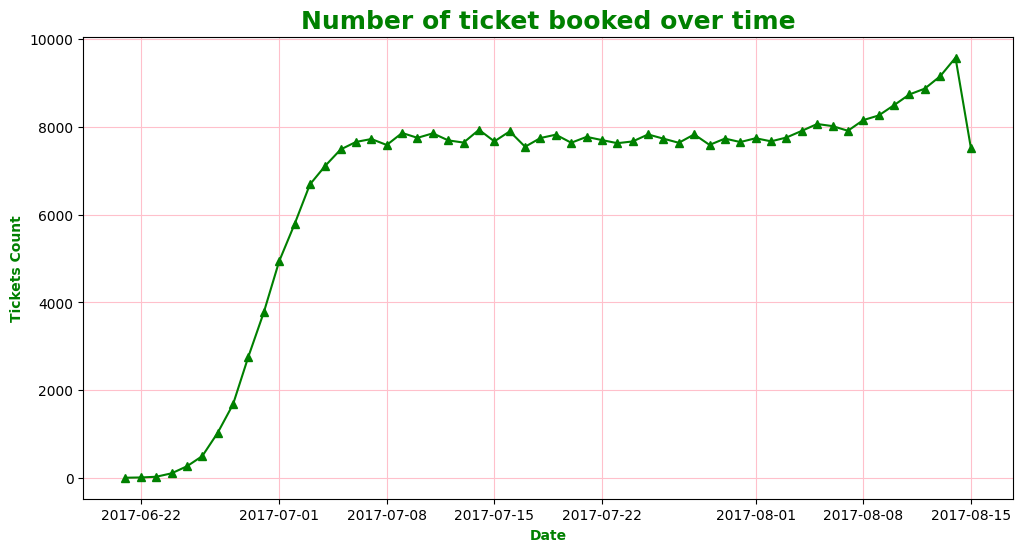

In [20]:
#making the line chart for the number of tickets booked in the dates
plt.figure(figsize = (12, 6))
plt.plot(date_group.index, date_group['date'], marker = '^', color = 'Green')
plt.xlabel('Date', color = "Green", fontweight = "bold")
plt.ylabel('Tickets Count', color = "Green", fontweight = "bold")
plt.title('Number of ticket booked over time', fontsize = 18, fontweight = "bold", color = 'Green')
plt.grid(True, color = "pink")
plt.show()

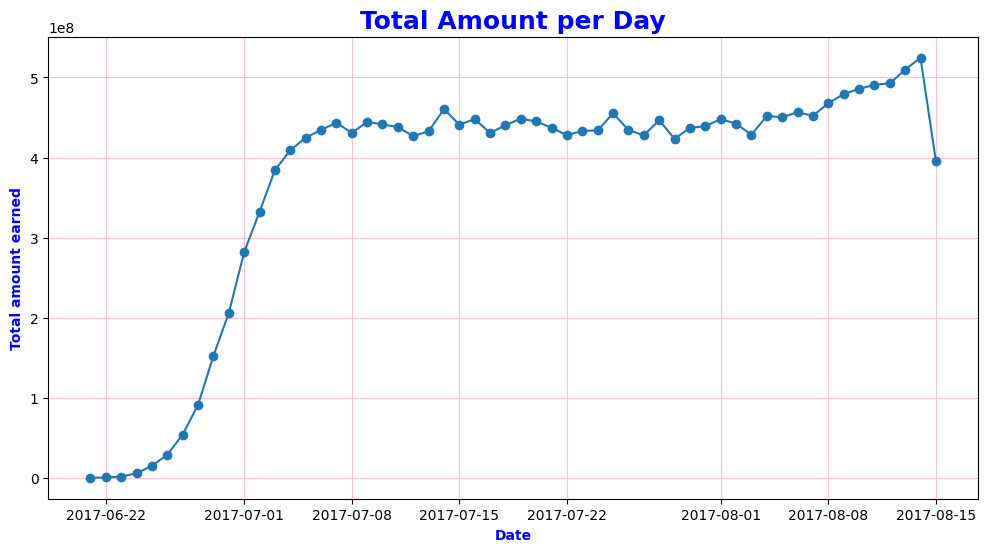

In [21]:
bookings =  pd.read_sql_query("select * from bookings", con)
bookings['book_date'] = pd.to_datetime(bookings['book_date'])
bookings['book_date'] = bookings['book_date'].dt.date
x = bookings.groupby('book_date')[['total_amount']].sum()
plt.figure(figsize = (12,6))
plt.plot(x.index, x[ 'total_amount'], marker = 'o')
plt.xlabel('Date', fontweight = 'bold', color = 'Blue')
plt.ylabel('Total amount earned', fontweight = 'bold', color = 'Blue')
plt.title('Total Amount per Day', fontsize = 18, fontweight = "bold", color = 'blue')
plt.grid(True, color = 'pink')
plt.show()

#### 3. Average charges for each aircraft with different fare conditions.

In [22]:
df = pd.read_sql_query("""select aircraft_code, fare_conditions, round(avg(amount),2) as Average_Cost
                  from ticket_flights join flights on ticket_flights.flight_id=flights.flight_id
                  group by aircraft_code, fare_conditions""", con)

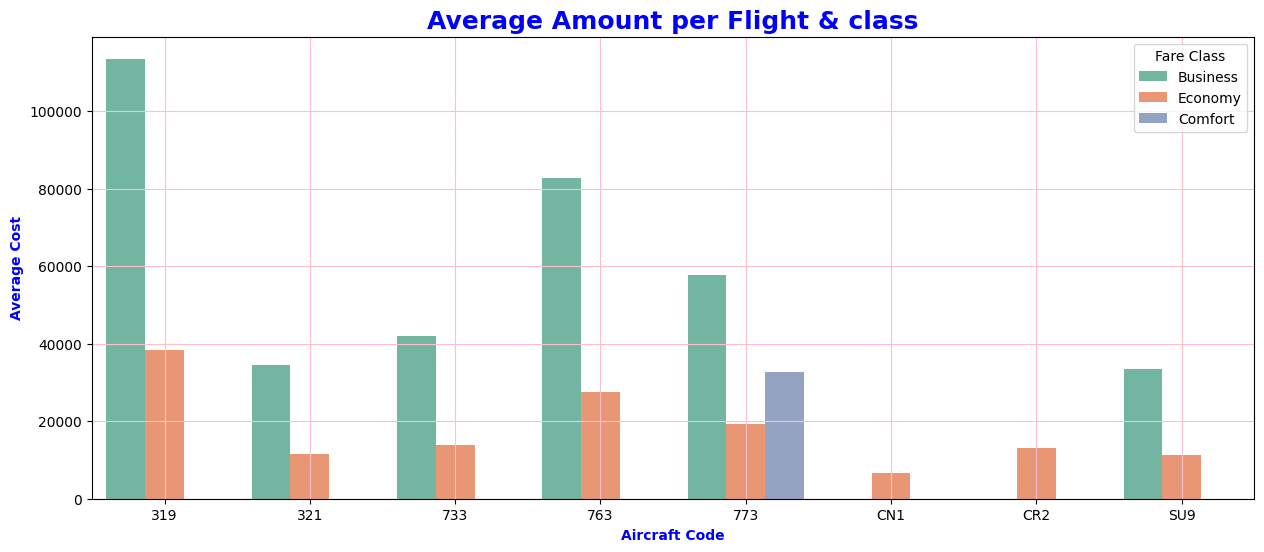

In [23]:
plt.figure(figsize= (15, 6))
sns.barplot(data = df, x = 'aircraft_code', y = 'Average_Cost', hue = "fare_conditions", palette = 'Set2')
plt.legend(title = 'Fare Class')
plt.xlabel('Aircraft Code', fontweight = 'bold', color = 'Blue')
plt.ylabel('Average Cost', fontweight = 'bold', color = 'Blue')
plt.title('Average Amount per Flight & class', fontsize = 18, fontweight = "bold", color = 'blue')
plt.grid(True, color = 'pink')
plt.show()

### Analyzing occupancy rate

Airlines must analyse their revenue streams in order to maximize profitability. The overall income per year and average revenue per ticket are important metrics to consider. This research also assists in pricing optimization and allocating more resources to profitable routes.

#### 1. For each aircraft, calculate the total revenue per year and the average revenue per ticket.

In [24]:
pd.read_sql_query("""select aircraft_code,ticket_count, total_revenue, total_revenue/ticket_count as avg_revenue_per_ticket from
                  (select aircraft_code, count(*) as ticket_count, sum(amount) as total_revenue from ticket_flights
                  join flights on ticket_flights.flight_id = flights.flight_id group by aircraft_code)""", con)

,aircraft_code,ticket_count,total_revenue,avg_revenue_per_ticket
0,319,52853,2706163100,51201
1,321,107129,1638164100,15291
2,733,86102,1426552100,16568
3,763,124774,4371277100,35033
4,773,144376,3431205500,23765
5,CN1,14672,96373800,6568
6,CR2,150122,1982760500,13207
7,SU9,365698,5114484700,13985


From the above table it is evident that, the aircraft with highest total revenue is **SU9** and from the barplot in the previous section we can deduce that the price of business class and economy is the lowest in this aircraft. This can be a contributing factor for increase in revenue as more number of people might opt for this aircraft ticket owing to it's comparitively lesser cost. 

The aircraft with the least total revenue is **CN1**, and the possible reason for this may be that it offers only economy class with the cheapest price per ticket and this may be due to poor conditions or less facilities and people may associate it with poor service and lower quality.

#### 2. Calculate the average occupancy per aircraft.

The average occupancy per aircraft is another critical number to consider. Airlines may measure how successfully they fill their seats and discover chances to boost occupancy rates with this metric. Higher occupancy rates can help airlines increase revenue and profit while decreasing operational expenses associated with empty seats. 

In [25]:
occupancy_rate = pd.read_sql_query("""select a.aircraft_code, avg(a.seats_count) as booked_seats, b.num_seats, avg(a.seats_count)/b.num_seats as occupancy_rate from
                    (select aircraft_code, flights.flight_id, count(*) as seats_count from boarding_passes 
                    inner join flights 
                    on boarding_passes.flight_id=flights.flight_id 
                    group by aircraft_code, flights.flight_id) AS a 
                    inner join
                    (select aircraft_code, count(*) as num_seats from seats group by aircraft_code) AS b
                    on a.aircraft_code = b.aircraft_code
                    group by a.aircraft_code
                    """, con)
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate
0,319,53.583181,116,0.461924
1,321,88.809231,170,0.522407
2,733,80.255462,130,0.617350
3,763,113.937294,222,0.513231
4,773,264.925806,402,0.659019
5,CN1,6.004431,12,0.500369
6,CR2,21.482847,50,0.429657
7,SU9,56.812113,97,0.585692


#### 3. Calculate by how much the total annual turnover could increase by giving all aircraft a 10% higher occupancy rate.

In [26]:
occupancy_rate['Inc occupancy rate'] = occupancy_rate['occupancy_rate']+occupancy_rate['occupancy_rate']*0.1
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate,Inc occupancy rate
0,319,53.583181,116,0.461924,0.508116
1,321,88.809231,170,0.522407,0.574648
2,733,80.255462,130,0.617350,0.679085
3,763,113.937294,222,0.513231,0.564554
4,773,264.925806,402,0.659019,0.724921
5,CN1,6.004431,12,0.500369,0.550406
6,CR2,21.482847,50,0.429657,0.472623
7,SU9,56.812113,97,0.585692,0.644261


In [45]:
pd.set_option("display.float_format", str)

In [47]:
total_revenue = pd.read_sql_query("""
SELECT aircraft_code, SUM(amount) AS total_revenue
FROM ticket_flights
JOIN flights 
ON ticket_flights.flight_id = flights.flight_id
GROUP BY aircraft_code
""", con)

In [48]:
occupancy_rate['Inc Annual Turnover'] = ((total_revenue['total_revenue'] / occupancy_rate['occupancy_rate']) * occupancy_rate['Inc occupancy rate'])

occupancy_rate['Inc Annual Turnover'] = round(occupancy_rate['Inc Annual Turnover'], 2)
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate,Inc occupancy rate,Inc Annual Turnover
0,319,53.58318098720292,116,0.46192397402761143,0.5081163714303726,2976779410.0
1,321,88.80923076923077,170,0.5224072398190045,0.574647963800905,1801980510.0
2,733,80.25546218487395,130,0.617349709114415,0.6790846800258565,1569207310.0
3,763,113.93729372937294,222,0.5132310528350132,0.5645541581185146,4808404810.0
4,773,264.9258064516129,402,0.659019419033863,0.7249213609372492,3774326050.0
5,CN1,6.004431314623338,12,0.5003692762186115,0.5504062038404727,106011180.0
6,CR2,21.48284690220174,50,0.42965693804403476,0.4726226318484382,2181036550.0
7,SU9,56.81211267605634,97,0.5856918832583128,0.644261071584144,5625933170.0


### Conclusion

To summarize, analyzing revenue data such as total revenue per year, average revenue per ticket, and average occupancy rate per aircraft is critical for airlines to maximize profitability. Airlines can find areas for improvement and modify their pricing to reflect the result of these indicators. A greater occupancy rate is one important feature that can enhance profitability by generating more revenue while minimizing operational costs associated with vacant seats. 

The airline should revise the price for each aircraft as keeping the price too low or two high drives customer ticket purchasing behavior. They should decide a reasonable price as per the facilities offered and the condition of the aircraft. 

## *Data preparation for dashboard*

In [ ]:
#Combine all relevant tables into one dataset for dashboarding
master_df = pd.read_sql_query("""
SELECT 
    tf.ticket_no,
    tf.flight_id,
    tf.fare_conditions,
    tf.amount,

    f.aircraft_code,
    f.departure_airport,
    f.arrival_airport,
    f.scheduled_departure,

    b.book_ref,
    b.book_date,
    b.total_amount

FROM ticket_flights tf
JOIN flights f ON tf.flight_id = f.flight_id
JOIN tickets t ON tf.ticket_no = t.ticket_no
JOIN bookings b ON t.book_ref = b.book_ref
""", con)

In [ ]:
# Convert date and create additional time features
master_df['book_date'] = pd.to_datetime(master_df['book_date'])
master_df['year'] = master_df['book_date'].dt.year
master_df['month'] = master_df['book_date'].dt.month
master_df['month_name'] = master_df['book_date'].dt.strftime('%b')

In [ ]:
# Export clean dataset for Power BI dashboard
master_df.to_csv("airline_master_data.csv", index=False)